# Black Hole Simulation Prototype

This notebook shows how the black hole concepts can become project code.

## What this notebook demonstrates

- Schwarzschild radius, photon sphere, and ISCO.
- Kerr horizons and ergosphere boundary.
- A simple particle trajectory model.
- Capture at the event horizon.
- How the notebook prototype maps to C++ classes.

In [2]:
import math
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

# Notebook convention:
# Use geometric units unless otherwise stated:
#
# G = c = 1
#
# In these units:
# Schwarzschild radius: r_s = 2M
# Photon sphere:        r_photon = 3M
# Schwarzschild ISCO:   r_ISCO = 6M

## 1. Geometric units

For a coding project, the cleanest first implementation is to use geometric units:

$$
G = c = 1
$$

This makes the most important Schwarzschild radii simple:

$$
r_s = 2M
$$

$$
r_{\text{photon}} = 3M
$$

$$
r_{\text{ISCO}} = 6M
$$

These are excellent values to expose in the simulation UI because they give users meaningful landmarks.

In [3]:
def schwarzschild_radius(M: float) -> float:
    return 2.0 * M

def photon_sphere_radius(M: float) -> float:
    return 3.0 * M

def schwarzschild_isco_radius(M: float) -> float:
    return 6.0 * M

M = 1.0

print("Schwarzschild black hole landmarks in geometric units:")
print(f"M                  = {M}")
print(f"event horizon r_s  = {schwarzschild_radius(M)}")
print(f"photon sphere      = {photon_sphere_radius(M)}")
print(f"ISCO               = {schwarzschild_isco_radius(M)}")

Schwarzschild black hole landmarks in geometric units:
M                  = 1.0
event horizon r_s  = 2.0
photon sphere      = 3.0
ISCO               = 6.0


## 2. Kerr horizons and ergosphere

For a rotating black hole, the outer and inner horizons are:

$$
r_+ = M + \sqrt{M^2 - a^2}
$$

$$
r_- = M - \sqrt{M^2 - a^2}
$$

The outer boundary of the ergosphere, also called the static limit, is:

$$
r_{\text{static}}(\theta)
=
M + \sqrt{M^2 - a^2\cos^2\theta}
$$

where:

- $M$ is the black hole mass.
- $a$ is the spin parameter.
- $\theta$ is the polar angle measured from the spin axis.

The ergosphere is the region between $r_+$ and $r_{\text{static}}$.

In [4]:
@dataclass
class KerrBlackHole:
    mass: float = 1.0
    spin: float = 0.0  # a, with |a| <= M in geometric units

    def is_valid(self) -> bool:
        return abs(self.spin) <= self.mass

    def horizons(self) -> tuple[float, float]:
        if not self.is_valid():
            raise ValueError("Kerr horizon does not exist when |a| > M.")
        root = math.sqrt(self.mass**2 - self.spin**2)
        r_outer = self.mass + root
        r_inner = self.mass - root
        return r_outer, r_inner

    def static_limit(self, theta):
        if not self.is_valid():
            raise ValueError("Kerr static limit requires |a| <= M.")
        return self.mass + np.sqrt(self.mass**2 - self.spin**2 * np.cos(theta)**2)


kerr = KerrBlackHole(mass=1.0, spin=0.85)
r_plus, r_minus = kerr.horizons()

print(f"Kerr black hole with M={kerr.mass}, a={kerr.spin}")
print(f"outer horizon r+ = {r_plus:.4f}")
print(f"inner horizon r- = {r_minus:.4f}")

Kerr black hole with M=1.0, a=0.85
outer horizon r+ = 1.5268
inner horizon r- = 0.4732


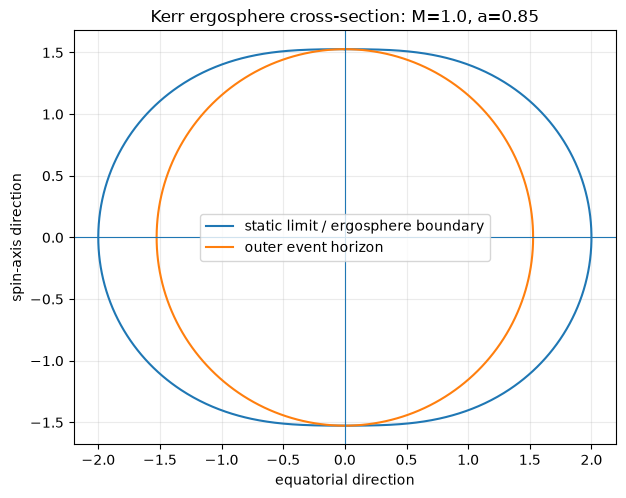

In [5]:
def plot_kerr_ergosphere(bh: KerrBlackHole) -> None:
    theta = np.linspace(0, 2*np.pi, 1000)

    r_static = bh.static_limit(theta)
    r_plus, _ = bh.horizons()

    # Polar-to-Cartesian cross-section.
    x_static = r_static * np.sin(theta)
    z_static = r_static * np.cos(theta)

    x_horizon = r_plus * np.sin(theta)
    z_horizon = r_plus * np.cos(theta)

    plt.figure(figsize=(7, 7))
    plt.plot(x_static, z_static, label="static limit / ergosphere boundary")
    plt.plot(x_horizon, z_horizon, label="outer event horizon")
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Kerr ergosphere cross-section: M={bh.mass}, a={bh.spin}")
    plt.xlabel("equatorial direction")
    plt.ylabel("spin-axis direction")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

plot_kerr_ergosphere(kerr)

## 3. A simple particle model

A full black hole simulation would integrate geodesics in the Schwarzschild or Kerr metric.

For a first project prototype, a useful educational model is a Newtonian gravitational acceleration plus a relativistic correction:

$$
\vec{a}
=
-\frac{M}{r^3}\vec{r}
\left(
1 + \frac{3L^2}{r^2}
\right)
$$

where:

- $\vec{r}$ is the particle position.
- $r = |\vec{r}|$.
- $L$ is angular momentum per unit mass.
- $M$ is black hole mass.

This is not exact general relativity, but it makes near-horizon orbits more unstable and visually demonstrates capture.

In [6]:
@dataclass
class Particle2D:
    position: np.ndarray
    velocity: np.ndarray


def angular_momentum_per_unit_mass(position: np.ndarray, velocity: np.ndarray) -> float:
    # 2D z-component of r x v
    return position[0] * velocity[1] - position[1] * velocity[0]


def black_hole_acceleration(position: np.ndarray, velocity: np.ndarray, M: float) -> np.ndarray:
    r = np.linalg.norm(position)
    if r == 0:
        return np.zeros(2)

    L = angular_momentum_per_unit_mass(position, velocity)
    correction = 1.0 + 3.0 * L**2 / r**2

    return -(M / r**3) * position * correction


def velocity_verlet_step(particle: Particle2D, M: float, dt: float) -> Particle2D:
    a1 = black_hole_acceleration(particle.position, particle.velocity, M)

    new_position = particle.position + particle.velocity * dt + 0.5 * a1 * dt**2
    a2 = black_hole_acceleration(new_position, particle.velocity, M)

    new_velocity = particle.velocity + 0.5 * (a1 + a2) * dt
    return Particle2D(new_position, new_velocity)


def simulate_particle(
    particle: Particle2D,
    M: float = 1.0,
    dt: float = 0.002,
    steps: int = 60000,
) -> tuple[np.ndarray, bool]:
    horizon = schwarzschild_radius(M)
    trajectory = []
    captured = False

    p = Particle2D(particle.position.copy(), particle.velocity.copy())

    for _ in range(steps):
        r = np.linalg.norm(p.position)
        trajectory.append(p.position.copy())

        if r <= horizon:
            captured = True
            break

        p = velocity_verlet_step(p, M, dt)

        # Stop very distant escapes to keep the notebook fast.
        if r > 80:
            break

    return np.array(trajectory), captured

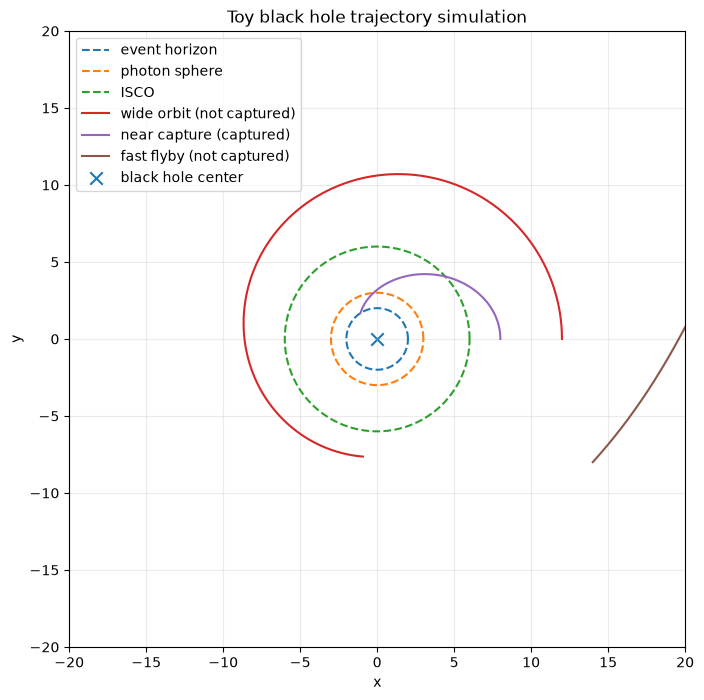

In [7]:
cases = {
    "wide orbit": Particle2D(np.array([12.0, 0.0]), np.array([0.0, 0.31])),
    "near capture": Particle2D(np.array([8.0, 0.0]), np.array([0.0, 0.26])),
    "fast flyby": Particle2D(np.array([14.0, -8.0]), np.array([0.30, 0.33])),
}

plt.figure(figsize=(8, 8))

theta = np.linspace(0, 2*np.pi, 500)
for radius, label in [
    (schwarzschild_radius(M), "event horizon"),
    (photon_sphere_radius(M), "photon sphere"),
    (schwarzschild_isco_radius(M), "ISCO"),
]:
    plt.plot(radius*np.cos(theta), radius*np.sin(theta), linestyle="--", label=label)

for name, particle in cases.items():
    trajectory, captured = simulate_particle(particle, M=M)
    label = f"{name} ({'captured' if captured else 'not captured'})"
    plt.plot(trajectory[:, 0], trajectory[:, 1], label=label)

plt.scatter([0], [0], marker="x", s=80, label="black hole center")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy black hole trajectory simulation")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 4. How this maps to C++

The notebook code can become a C++ module with the following structure:

```cpp
struct Vec2 {
    double x;
    double y;
};

struct Particle {
    Vec2 position;
    Vec2 velocity;
};

struct SchwarzschildBlackHole {
    double mass;

    double eventHorizon() const {
        return 2.0 * mass;
    }

    double photonSphere() const {
        return 3.0 * mass;
    }

    double isco() const {
        return 6.0 * mass;
    }
};

struct KerrBlackHole {
    double mass;
    double spin;

    bool hasHorizon() const {
        return std::abs(spin) <= mass;
    }

    double outerHorizon() const {
        return mass + std::sqrt(mass * mass - spin * spin);
    }

    double innerHorizon() const {
        return mass - std::sqrt(mass * mass - spin * spin);
    }

    double staticLimit(double theta) const {
        return mass + std::sqrt(
            mass * mass - spin * spin * std::cos(theta) * std::cos(theta)
        );
    }
};
```

In the project, the C++ side should handle the physics state, while the browser or visualization layer should draw:

- the event horizon,
- photon sphere,
- ISCO,
- ergosphere,
- particle trails,
- captured or escaped status.